In [31]:
import requests
import pandas as pd
import math

BASE_URL = (
    "https://services.arcgis.com/v400IkDOw1ad7Yad/ArcGIS/rest/services/"
    "Ask_Raleigh_Requests/FeatureServer/0/query"
)

session = requests.Session()
BATCH_SIZE = 500
min_id = 1
max_id = 8983
all_rows = []

batches = math.ceil((max_id - min_id + 1) / BATCH_SIZE)

for i in range(batches):
    low  = min_id + i * BATCH_SIZE
    high = low + BATCH_SIZE - 1

    params = {
        "where": f"OBJECTID >= {low} AND OBJECTID <= {high}",
        "outFields": "*",
        "returnGeometry": "false",
        "orderByFields": "OBJECTID ASC",
        "f": "json",
    }

    resp = session.get(BASE_URL, params=params, timeout=60)
    resp.raise_for_status()
    data = resp.json()

    features = data.get("features", [])
    rows = [f["attributes"] for f in features]
    all_rows.extend(rows)

    if data.get("exceededTransferLimit"):
        print(f"Batch {i+1}/{batches} — WARNING: still hitting limit! rows={len(rows)}")
    else:
        print(f"Batch {i+1}/{batches} — OK | rows: {len(rows)} | total so far: {len(all_rows)}")

df_full = pd.DataFrame(all_rows)
df_full.to_csv("ask_raleigh_full.csv", index=False)

print(f"\nTotal records fetched: {len(df_full)}")
print(f"Expected:              8983")
print(f"Missing:               {8983 - len(df_full)}")
print(f"\nCategories found:")
print(df_full["CATEGORY"].value_counts())

Batch 1/18 — OK | rows: 500 | total so far: 500
Batch 2/18 — OK | rows: 500 | total so far: 1000
Batch 3/18 — OK | rows: 500 | total so far: 1500
Batch 4/18 — OK | rows: 500 | total so far: 2000
Batch 5/18 — OK | rows: 500 | total so far: 2500
Batch 6/18 — OK | rows: 500 | total so far: 3000
Batch 7/18 — OK | rows: 500 | total so far: 3500
Batch 8/18 — OK | rows: 500 | total so far: 4000
Batch 9/18 — OK | rows: 500 | total so far: 4500
Batch 10/18 — OK | rows: 500 | total so far: 5000
Batch 11/18 — OK | rows: 500 | total so far: 5500
Batch 12/18 — OK | rows: 500 | total so far: 6000
Batch 13/18 — OK | rows: 500 | total so far: 6500
Batch 14/18 — OK | rows: 500 | total so far: 7000
Batch 15/18 — OK | rows: 500 | total so far: 7500
Batch 16/18 — OK | rows: 500 | total so far: 8000
Batch 17/18 — OK | rows: 500 | total so far: 8500
Batch 18/18 — OK | rows: 483 | total so far: 8983

Total records fetched: 8983
Expected:              8983
Missing:               0

Categories found:
CATEGORY


In [32]:
import pandas as pd

# Parse full dataset
df_full["APPLIED_DATE"] = pd.to_datetime(df_full["APPLIED_DATE"], unit="ms", errors="coerce")
df_full["week"] = df_full["APPLIED_DATE"].dt.to_period("W").dt.start_time

# Weekly counts per category
weekly = (
    df_full.groupby(["week", "CATEGORY"])
    .size()
    .reset_index(name="request_count")
)

# Summary per category
summary = (
    weekly.groupby("CATEGORY")["request_count"]
    .agg(
        total="sum",
        weeks="count",
        mean="mean",
        std="std",
        zero_weeks=lambda x: (x == 0).sum()
    )
)
summary["cv"] = (summary["std"] / summary["mean"]).round(2)
summary = summary.sort_values("total", ascending=False)

print(f"Date range: {df_full['APPLIED_DATE'].min().date()} to {df_full['APPLIED_DATE'].max().date()}")
print(f"Total records: {len(df_full)}")
print(f"Total weeks in dataset: {df_full['week'].nunique()}")
print()
print(summary.to_string())

Date range: 2025-04-03 to 2026-04-09
Total records: 8983
Total weeks in dataset: 54

                            total  weeks       mean        std  zero_weeks    cv
CATEGORY                                                                        
Transportation & Mobility    2685     53  50.660377  32.731391           0  0.65
Permits & Planning           1418     48  29.541667  25.179321           0  0.85
Housing & Neighborhoods      1216     41  29.658537  20.321921           0  0.69
Parks & Recreation            791     53  14.924528   8.779016           0  0.59
Public Nuisance               676     13  52.000000  21.432063           0  0.41
Customer Experience           666     53  12.566038   6.837424           0  0.54
Neighborhood & Environment    504     32  15.750000   9.919027           0  0.63
Dead Animals                  327     43   7.604651   4.129681           0  0.54
Stormwater & Water            205     44   4.659091   3.079891           0  0.66
Buses                   

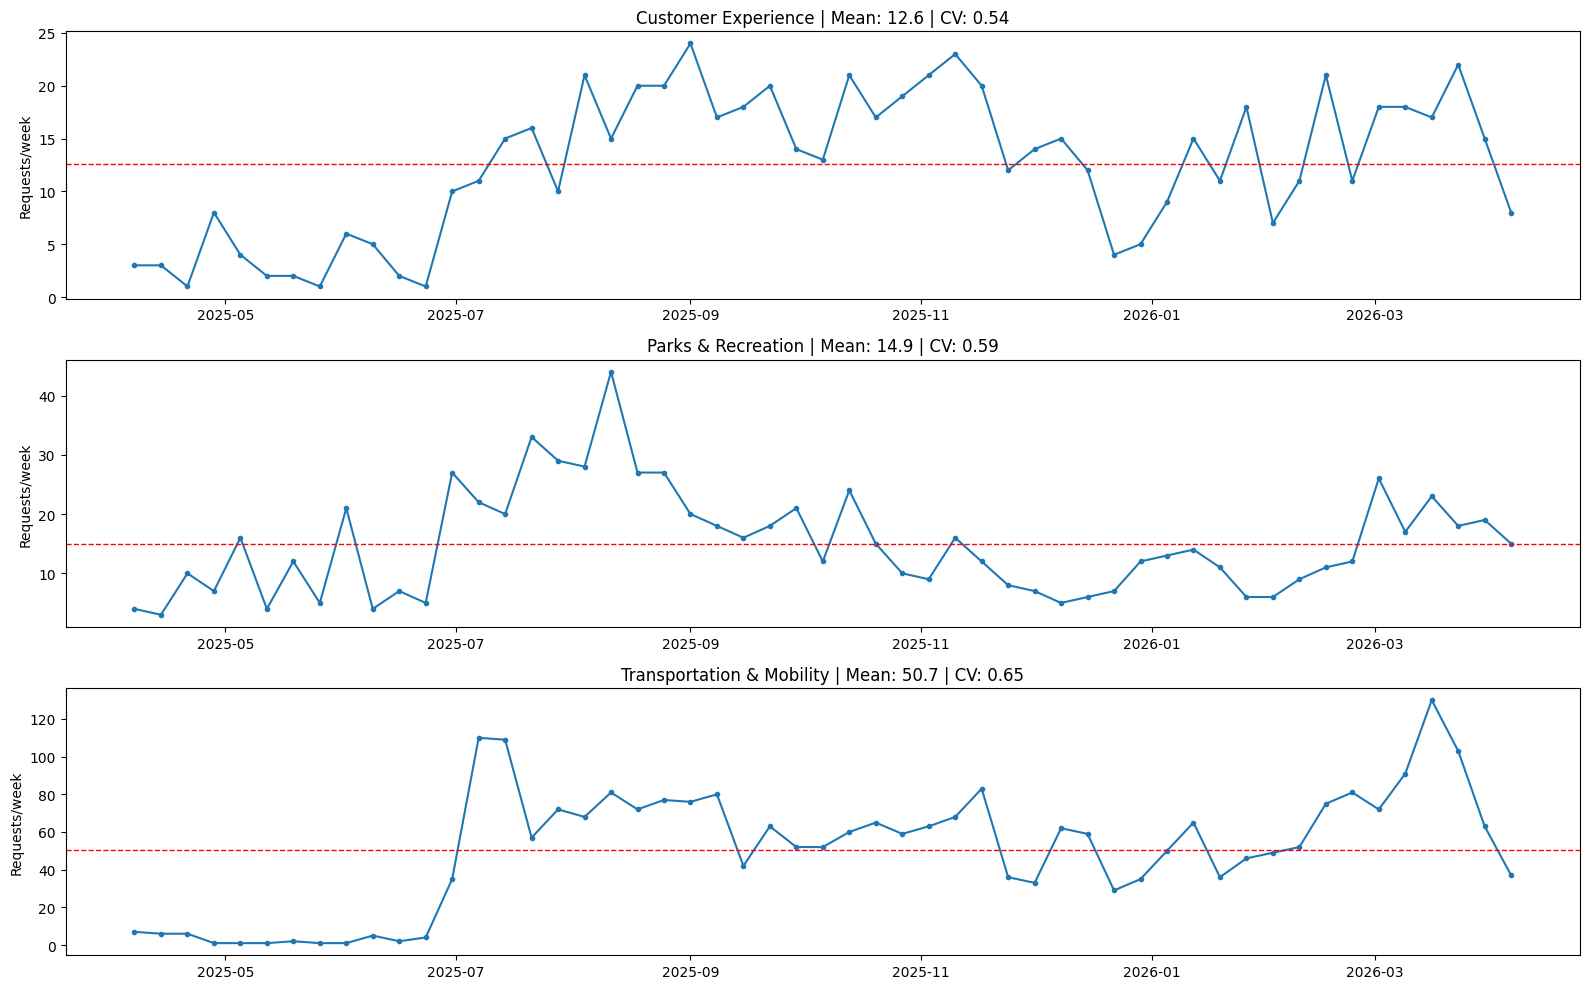

In [33]:
import matplotlib.pyplot as plt

cats = ["Customer Experience", "Parks & Recreation", "Transportation & Mobility"]

fig, axes = plt.subplots(3, 1, figsize=(16, 10))

for ax, cat in zip(axes, cats):
    series = (
        weekly[weekly["CATEGORY"] == cat]
        .sort_values("week")
        .set_index("week")["request_count"]
    )
    ax.plot(series.index, series.values, marker="o", markersize=3)
    ax.axhline(series.mean(), color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{cat} | Mean: {series.mean():.1f} | CV: {series.std()/series.mean():.2f}")
    ax.set_ylabel("Requests/week")

plt.tight_layout()
plt.savefig("results/category_comparison.png", dpi=150)
plt.show()

In [34]:
import pandas as pd

series_ce = (
    weekly[weekly["CATEGORY"] == "Customer Experience"]
    .sort_values("week")
    .set_index("week")["request_count"]
)

# Trim early ramp — start from July 2025 when signal stabilizes
series_ce = series_ce["2025-07-01":]

print(f"Total weeks after trim: {len(series_ce)}")
print(f"Zero weeks: {(series_ce == 0).sum()}")
print(f"Mean: {series_ce.mean():.1f}")
print(f"Std:  {series_ce.std():.1f}")
print(f"CV:   {series_ce.std()/series_ce.mean():.2f}")
print(f"Date range: {series_ce.index.min().date()} to {series_ce.index.max().date()}")
print()
print(series_ce.to_string())

Total weeks after trim: 40
Zero weeks: 0
Mean: 15.4
Std:  5.0
CV:   0.32
Date range: 2025-07-07 to 2026-04-06

week
2025-07-07    11
2025-07-14    15
2025-07-21    16
2025-07-28    10
2025-08-04    21
2025-08-11    15
2025-08-18    20
2025-08-25    20
2025-09-01    24
2025-09-08    17
2025-09-15    18
2025-09-22    20
2025-09-29    14
2025-10-06    13
2025-10-13    21
2025-10-20    17
2025-10-27    19
2025-11-03    21
2025-11-10    23
2025-11-17    20
2025-11-24    12
2025-12-01    14
2025-12-08    15
2025-12-15    12
2025-12-22     4
2025-12-29     5
2026-01-05     9
2026-01-12    15
2026-01-19    11
2026-01-26    18
2026-02-02     7
2026-02-09    11
2026-02-16    21
2026-02-23    11
2026-03-02    18
2026-03-09    18
2026-03-16    17
2026-03-23    22
2026-03-30    15
2026-04-06     8


In [35]:
import warnings
from statsmodels.tools.sm_exceptions import ValueWarning
warnings.filterwarnings("ignore", category=ValueWarning)

Note: val set reserved for LSTM hyperparameter tuning in PF3

Baseline models use train only; test set is held out

Train: 28 weeks | 2025-07-07 to 2026-01-12
Val:   6 weeks  | 2026-01-19 to 2026-02-23
Test:  6 weeks  | 2026-03-02 to 2026-04-06
Test mean: 16.3

Lag-4 Naive  — MAE: 7.67, RMSE: 8.33, MAE%: 46.9%
Moving Avg   — MAE: 3.08,  RMSE: 3.77, MAE%: 18.9%
ARIMA (1, 1, 1) — MAE: 3.59, RMSE: 4.41, MAE%: 22.0%


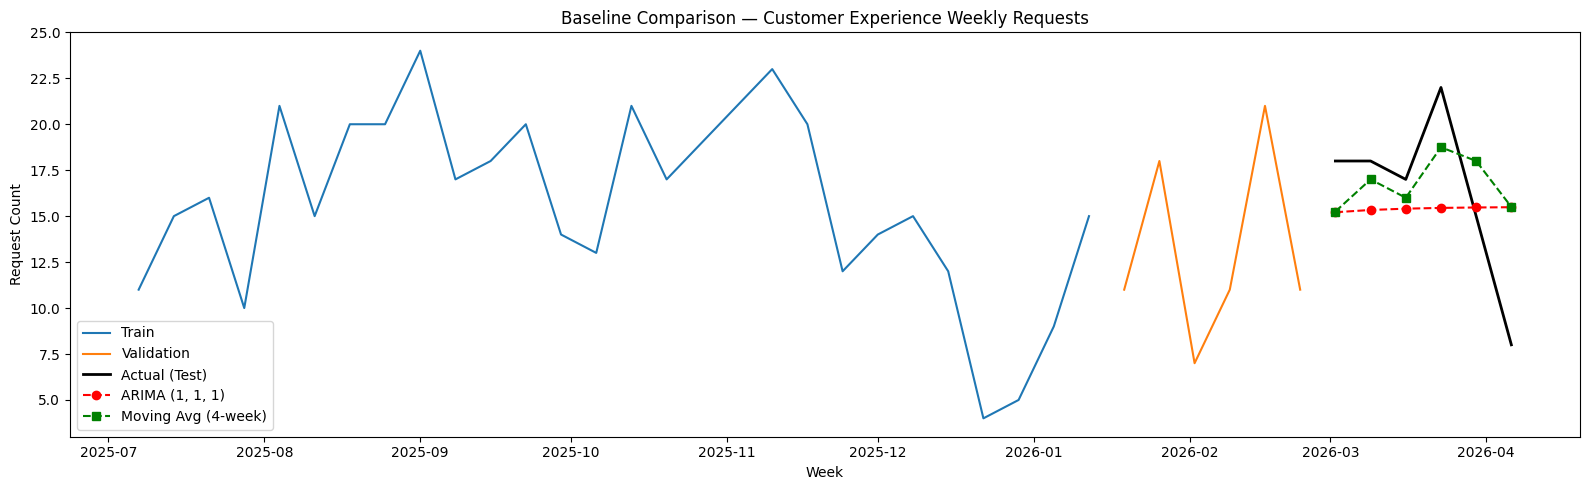

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Split
train = series_ce.iloc[:28]
val   = series_ce.iloc[28:34]
test  = series_ce.iloc[34:]

print(f"Train: {len(train)} weeks | {train.index[0].date()} to {train.index[-1].date()}")
print(f"Val:   {len(val)} weeks  | {val.index[0].date()} to {val.index[-1].date()}")
print(f"Test:  {len(test)} weeks  | {test.index[0].date()} to {test.index[-1].date()}")
print(f"Test mean: {test.mean():.1f}")
print()

# Lag-4 Naive
naive = series_ce.shift(4).iloc[34:]
naive_mae  = mean_absolute_error(test, naive)
naive_rmse = np.sqrt(mean_squared_error(test, naive))

# Moving Average
ma = series_ce.rolling(4).mean().iloc[34:]
ma_mae  = mean_absolute_error(test, ma)
ma_rmse = np.sqrt(mean_squared_error(test, ma))

# ARIMA - try a few orders
best_arima_mae = float("inf")
best_order = None
best_forecast = None

for order in [(1,1,1),(2,1,1),(1,1,2),(0,1,1),(1,0,1),(2,1,0)]:
    try:
        res = ARIMA(train, order=order).fit()
        fc  = res.forecast(steps=6)
        mae = mean_absolute_error(test, fc)
        if mae < best_arima_mae:
            best_arima_mae = mae
            best_order = order
            best_forecast = fc
    except:
        pass

arima_rmse = np.sqrt(mean_squared_error(test, best_forecast))

print(f"Lag-4 Naive  — MAE: {naive_mae:.2f}, RMSE: {naive_rmse:.2f}, MAE%: {naive_mae/test.mean()*100:.1f}%")
print(f"Moving Avg   — MAE: {ma_mae:.2f},  RMSE: {ma_rmse:.2f}, MAE%: {ma_mae/test.mean()*100:.1f}%")
print(f"ARIMA {best_order} — MAE: {best_arima_mae:.2f}, RMSE: {arima_rmse:.2f}, MAE%: {best_arima_mae/test.mean()*100:.1f}%")

# Plot
plt.figure(figsize=(16, 5))
plt.plot(train.index, train, label="Train")
plt.plot(val.index,   val,   label="Validation")
plt.plot(test.index,  test,  label="Actual (Test)", color="black", linewidth=2)
plt.plot(test.index,  best_forecast, label=f"ARIMA {best_order}",
         linestyle="--", marker="o", color="red")
plt.plot(test.index,  ma, label="Moving Avg (4-week)",
         linestyle="--", marker="s", color="green")
plt.title("Baseline Comparison — Customer Experience Weekly Requests")
plt.xlabel("Week")
plt.ylabel("Request Count")
plt.legend()
plt.tight_layout()
plt.savefig("results/ce_baseline.png", dpi=150)
plt.show()

In [37]:
print(f"Source: City of Raleigh Open Data Portal — Ask Raleigh Requests")
print(f"Total records fetched: {len(df_full)}")
print(f"Date range: {df_full['APPLIED_DATE'].min().date()} to {df_full['APPLIED_DATE'].max().date()}")
print(f"Total categories: {df_full['CATEGORY'].nunique()}")
print(f"\nNote: Original API capped at 4,983 records.")
print(f"Fixed using OBJECTID range batching — retrieved all 8,983 records.")
print(f"\nCategory breakdown:")
print(df_full["CATEGORY"].value_counts())

Source: City of Raleigh Open Data Portal — Ask Raleigh Requests
Total records fetched: 8983
Date range: 2025-04-03 to 2026-04-09
Total categories: 12

Note: Original API capped at 4,983 records.
Fixed using OBJECTID range batching — retrieved all 8,983 records.

Category breakdown:
CATEGORY
Transportation & Mobility     2685
Permits & Planning            1418
Housing & Neighborhoods       1216
Parks & Recreation             791
Public Nuisance                676
Customer Experience            666
Neighborhood & Environment     504
Dead Animals                   327
Stormwater & Water             205
Buses                          127
Noise Feedback                 102
Leaf Service (Seasonal)          5
Name: count, dtype: int64


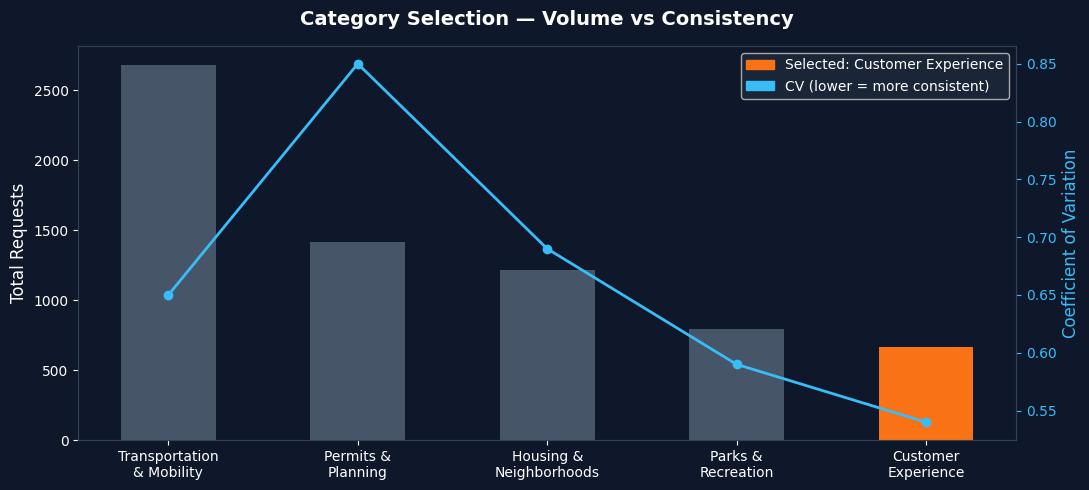

Saved: slide_category_selection.png


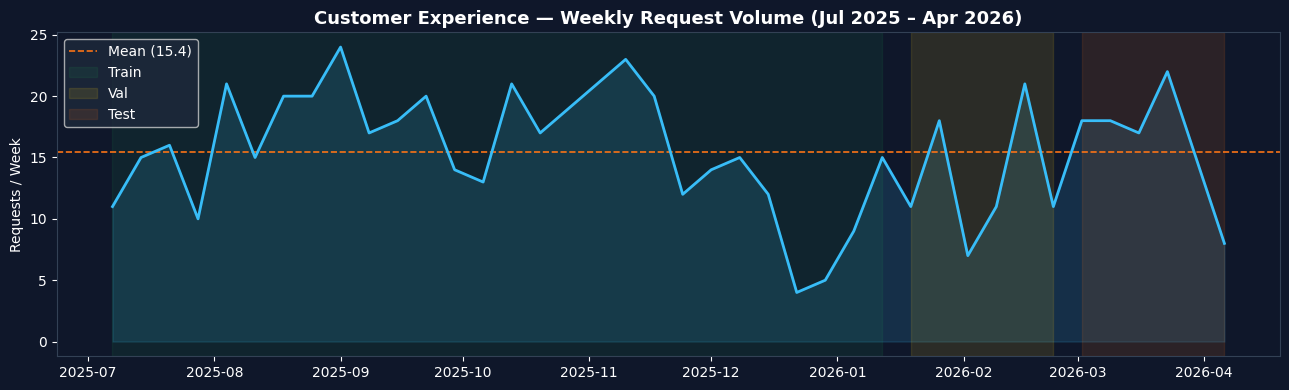

Saved: slide_timeseries.png


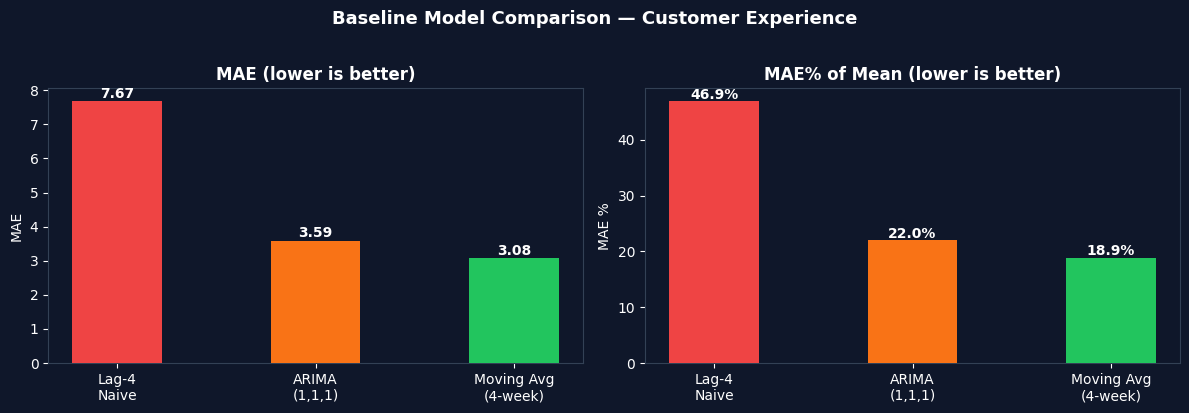

Saved: slide_baseline_results.png


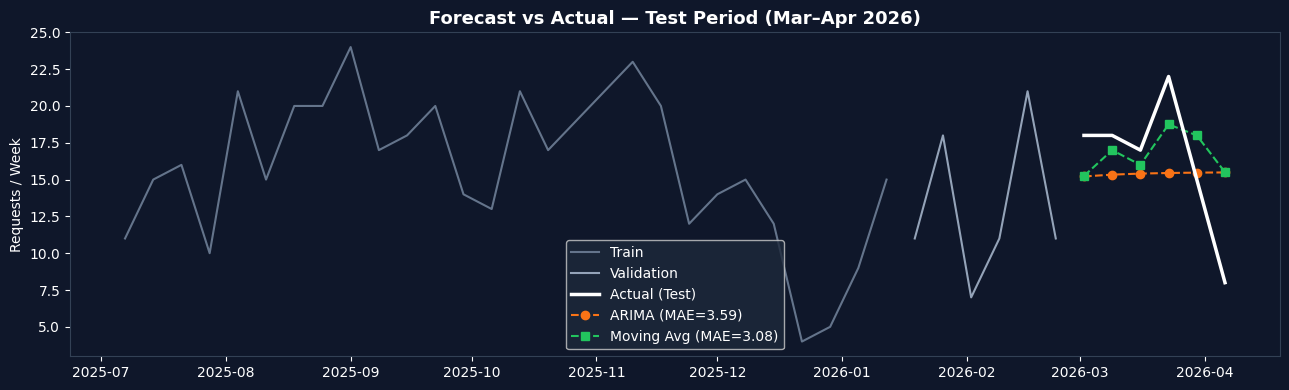

Saved: slide_forecast.png

All 4 slide visuals saved to results/


In [38]:
import warnings
import os
warnings.filterwarnings("ignore")
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

os.makedirs("results", exist_ok=True)

# ── 1. Category comparison bar chart ─────────────────────────────────────────
cats = ["Transportation\n& Mobility", "Permits &\nPlanning",
        "Housing &\nNeighborhoods", "Parks &\nRecreation",
        "Customer\nExperience"]
totals = [2685, 1418, 1216, 791, 666]
cvs    = [0.65, 0.85, 0.69, 0.59, 0.54]
colors = ["#475569","#475569","#475569","#475569","#f97316"]

fig, ax1 = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor("#0f172a")
ax1.set_facecolor("#0f172a")
bars = ax1.bar(cats, totals, color=colors, width=0.5, zorder=3)
ax1.set_ylabel("Total Requests", color="white", fontsize=12)
ax1.tick_params(colors="white")
ax1.spines[["top","right","left","bottom"]].set_color("#334155")
for spine in ax1.spines.values():
    spine.set_color("#334155")
ax1.yaxis.label.set_color("white")
ax1.tick_params(axis="both", colors="white")

ax2 = ax1.twinx()
ax2.plot(cats, cvs, color="#38bdf8", marker="o", linewidth=2, zorder=4, label="CV (lower=better)")
ax2.set_ylabel("Coefficient of Variation", color="#38bdf8", fontsize=12)
ax2.tick_params(colors="#38bdf8")
ax2.set_facecolor("#0f172a")
for spine in ax2.spines.values():
    spine.set_color("#334155")

ax1.set_title("Category Selection — Volume vs Consistency",
              color="white", fontsize=14, pad=15, fontweight="bold")
highlight = mpatches.Patch(color="#f97316", label="Selected: Customer Experience")
cv_line   = mpatches.Patch(color="#38bdf8", label="CV (lower = more consistent)")
ax1.legend(handles=[highlight, cv_line],
           facecolor="#1e293b", labelcolor="white", loc="upper right")
plt.tight_layout()
plt.savefig("results/slide_category_selection.png", dpi=150, bbox_inches="tight",
            facecolor="#0f172a")
plt.show()
print("Saved: slide_category_selection.png")

# ── 2. Clean time series ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
fig.patch.set_facecolor("#0f172a")
ax.set_facecolor("#0f172a")

ax.plot(series_ce.index, series_ce.values, color="#38bdf8", linewidth=2, zorder=3)
ax.fill_between(series_ce.index, series_ce.values, alpha=0.15, color="#38bdf8")
ax.axhline(series_ce.mean(), color="#f97316", linestyle="--", linewidth=1.2,
           label=f"Mean ({series_ce.mean():.1f})")

# Shade train/val/test
ax.axvspan(train.index[0], train.index[-1], alpha=0.08, color="#22c55e", label="Train")
ax.axvspan(val.index[0],   val.index[-1],   alpha=0.12, color="#facc15", label="Val")
ax.axvspan(test.index[0],  test.index[-1],  alpha=0.12, color="#f97316", label="Test")

ax.set_title("Customer Experience — Weekly Request Volume (Jul 2025 – Apr 2026)",
             color="white", fontsize=13, fontweight="bold")
ax.set_ylabel("Requests / Week", color="white")
ax.tick_params(colors="white")
for spine in ax.spines.values():
    spine.set_color("#334155")
ax.legend(facecolor="#1e293b", labelcolor="white")
plt.tight_layout()
plt.savefig("results/slide_timeseries.png", dpi=150, bbox_inches="tight",
            facecolor="#0f172a")
plt.show()
print("Saved: slide_timeseries.png")

# ── 3. Baseline results bar chart ─────────────────────────────────────────────
models = ["Lag-4\nNaive", "ARIMA\n(1,1,1)", "Moving Avg\n(4-week)"]
maes   = [7.67, 3.59, 3.08]
maepct = [46.9, 22.0, 18.9]
bcolors = ["#ef4444", "#f97316", "#22c55e"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor("#0f172a")

for ax in axes:
    ax.set_facecolor("#0f172a")
    for spine in ax.spines.values():
        spine.set_color("#334155")
    ax.tick_params(colors="white")

axes[0].bar(models, maes, color=bcolors, width=0.45, zorder=3)
axes[0].set_title("MAE (lower is better)", color="white", fontweight="bold")
axes[0].set_ylabel("MAE", color="white")
for i, v in enumerate(maes):
    axes[0].text(i, v + 0.1, str(v), ha="center", color="white", fontweight="bold")

axes[1].bar(models, maepct, color=bcolors, width=0.45, zorder=3)
axes[1].set_title("MAE% of Mean (lower is better)", color="white", fontweight="bold")
axes[1].set_ylabel("MAE %", color="white")
for i, v in enumerate(maepct):
    axes[1].text(i, v + 0.5, f"{v}%", ha="center", color="white", fontweight="bold")

fig.suptitle("Baseline Model Comparison — Customer Experience",
             color="white", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("results/slide_baseline_results.png", dpi=150, bbox_inches="tight",
            facecolor="#0f172a")
plt.show()
print("Saved: slide_baseline_results.png")

# ── 4. Forecast vs actual ─────────────────────────────────────────────────────
from statsmodels.tsa.arima.model import ARIMA

arima_fc = ARIMA(train, order=(1,1,1)).fit().forecast(steps=6)
ma_fc    = series_ce.rolling(4).mean().iloc[34:]

fig, ax = plt.subplots(figsize=(13, 4))
fig.patch.set_facecolor("#0f172a")
ax.set_facecolor("#0f172a")

ax.plot(train.index, train, color="#64748b", linewidth=1.5, label="Train")
ax.plot(val.index,   val,   color="#94a3b8", linewidth=1.5, label="Validation")
ax.plot(test.index,  test,  color="white",   linewidth=2.5, label="Actual (Test)", zorder=5)
ax.plot(test.index,  arima_fc, color="#f97316", linestyle="--",
        marker="o", markersize=6, label=f"ARIMA (MAE=3.59)", zorder=4)
ax.plot(test.index,  ma_fc,    color="#22c55e", linestyle="--",
        marker="s", markersize=6, label=f"Moving Avg (MAE=3.08)", zorder=4)

ax.set_title("Forecast vs Actual — Test Period (Mar–Apr 2026)",
             color="white", fontsize=13, fontweight="bold")
ax.set_ylabel("Requests / Week", color="white")
ax.tick_params(colors="white")
for spine in ax.spines.values():
    spine.set_color("#334155")
ax.legend(facecolor="#1e293b", labelcolor="white")
plt.tight_layout()
plt.savefig("results/slide_forecast.png", dpi=150, bbox_inches="tight",
            facecolor="#0f172a")
plt.show()
print("Saved: slide_forecast.png")

print("\nAll 4 slide visuals saved to results/")

## LSTM Forecasting

Cells A–F build, tune, and evaluate the LSTM model, then generate PPT-ready visuals.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# LSTM — Cell A: Imports
# ─────────────────────────────────────────────────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# LSTM — Cell B: Prepare scaled sequences
# series_ce / train / val / test are already defined in Cell 6 above
# ─────────────────────────────────────────────────────────────────────────────
WINDOW = 4          # look-back weeks
FORECAST_STEPS = 6  # weeks to forecast (matches test set size)

scaler = MinMaxScaler()
train_scaled    = scaler.fit_transform(train.values.reshape(-1, 1)).flatten()
val_scaled      = scaler.transform(val.values.reshape(-1, 1)).flatten()
test_scaled     = scaler.transform(test.values.reshape(-1, 1)).flatten()
trainval_scaled = np.concatenate([train_scaled, val_scaled])

def make_sequences(arr, window):
    X, y = [], []
    for i in range(len(arr) - window):
        X.append(arr[i : i + window])
        y.append(arr[i + window])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = make_sequences(train_scaled, WINDOW)

full_for_val     = np.concatenate([train_scaled, val_scaled])
X_val_full, y_val_full = make_sequences(full_for_val, WINDOW)
X_val   = X_val_full[-len(val):]
y_val   = y_val_full[-len(val):]

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}    y_val:   {y_val.shape}")
print(f"Scaler range: [{scaler.data_min_[0]:.1f}, {scaler.data_max_[0]:.1f}]")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# LSTM — Cell C: Model definition
# ─────────────────────────────────────────────────────────────────────────────
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=2,
                 dropout=0.2, output_size=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

print("LSTMForecaster defined.")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# LSTM — Cell D: Hyperparameter grid search (val set)
# ─────────────────────────────────────────────────────────────────────────────
from itertools import product as iterproduct

param_grid = {
    "hidden_size": [16, 32, 64],
    "num_layers":  [1, 2],
    "dropout":     [0.0, 0.2],
    "lr":          [1e-3, 5e-4],
}
EPOCHS   = 200
PATIENCE = 30

def make_loader(X, y, batch_size=8, shuffle=True):
    Xt = torch.tensor(X).unsqueeze(-1)
    yt = torch.tensor(y)
    return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=shuffle)

loader_train = make_loader(X_train, y_train, shuffle=True)
loader_val   = make_loader(X_val,   y_val,   shuffle=False)

best_val_mae = float("inf")
best_params  = None
best_state   = None
results_grid = []

combos = list(iterproduct(*param_grid.values()))
keys   = list(param_grid.keys())
print(f"Testing {len(combos)} combos …")

for combo in combos:
    p  = dict(zip(keys, combo))
    model = LSTMForecaster(hidden_size=p["hidden_size"],
                           num_layers=p["num_layers"],
                           dropout=p["dropout"]).to(device)
    opt  = torch.optim.Adam(model.parameters(), lr=p["lr"])
    crit = nn.MSELoss()

    best_v, best_s, no_imp = float("inf"), None, 0
    for epoch in range(EPOCHS):
        model.train()
        for Xb, yb in loader_train:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            crit(model(Xb), yb).backward()
            opt.step()

        model.eval()
        with torch.no_grad():
            vp = torch.cat([model(Xb.to(device)).cpu() for Xb, _ in loader_val])
        vl = ((vp.numpy() - y_val) ** 2).mean()
        if vl < best_v:
            best_v = vl
            best_s = {k: v.clone() for k, v in model.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1
            if no_imp >= PATIENCE:
                break

    model.load_state_dict(best_s)
    model.eval()
    with torch.no_grad():
        pv = model(torch.tensor(X_val).unsqueeze(-1).to(device)).cpu().numpy()
    pv_real  = scaler.inverse_transform(pv.reshape(-1, 1)).flatten()
    val_mae  = mean_absolute_error(val.values, pv_real)
    results_grid.append({**p, "val_mae": round(val_mae, 3)})
    print(f"  {p}  val_mae={val_mae:.3f}")

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_params  = p
        best_state   = best_s

print(f"\nBest val MAE: {best_val_mae:.3f}")
print(f"Best params:  {best_params}")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# LSTM — Cell E: Retrain on train+val, forecast test, compute metrics
# ─────────────────────────────────────────────────────────────────────────────
model_final = LSTMForecaster(
    hidden_size=best_params["hidden_size"],
    num_layers=best_params["num_layers"],
    dropout=best_params["dropout"]
).to(device)
opt_final = torch.optim.Adam(model_final.parameters(), lr=best_params["lr"])
crit      = nn.MSELoss()

X_tv, y_tv   = make_sequences(trainval_scaled, WINDOW)
loader_tv    = make_loader(X_tv, y_tv, shuffle=True)

model_final.train()
for epoch in range(300):
    for Xb, yb in loader_tv:
        Xb, yb = Xb.to(device), yb.to(device)
        opt_final.zero_grad()
        crit(model_final(Xb), yb).backward()
        opt_final.step()
print("Retrained on train+val.")

# Recursive 6-step forecast
model_final.eval()
context = list(trainval_scaled[-WINDOW:])
lstm_preds_scaled = []
with torch.no_grad():
    for _ in range(FORECAST_STEPS):
        x = torch.tensor(context[-WINDOW:], dtype=torch.float32)
        x = x.unsqueeze(0).unsqueeze(-1).to(device)
        pred = model_final(x).item()
        lstm_preds_scaled.append(pred)
        context.append(pred)

lstm_preds = scaler.inverse_transform(
    np.array(lstm_preds_scaled).reshape(-1, 1)
).flatten()

lstm_mae  = mean_absolute_error(test.values, lstm_preds)
lstm_rmse = np.sqrt(mean_squared_error(test.values, lstm_preds))
lstm_mape = np.mean(np.abs((test.values - lstm_preds) / test.values)) * 100

print("\n── Test Set Metrics ──────────────────────────────────────────")
print(f"{'Model':<24} {'MAE':>6} {'RMSE':>6} {'MAPE':>7}")
print("-" * 48)
print(f"{'Lag-4 Naive':<24} {naive_mae:>6.2f} {naive_rmse:>6.2f} {naive_mae/test.mean()*100:>6.1f}%")
print(f"{'Moving Avg (4-wk)':<24} {ma_mae:>6.2f} {ma_rmse:>6.2f} {ma_mae/test.mean()*100:>6.1f}%")
print(f"{'ARIMA best':<24} {best_arima_mae:>6.2f} {arima_rmse:>6.2f} {best_arima_mae/test.mean()*100:>6.1f}%")
print(f"{'LSTM (stacked)':<24} {lstm_mae:>6.2f} {lstm_rmse:>6.2f} {lstm_mape:>6.1f}%")
print()
print(f"LSTM vs Moving Avg  (best baseline): {(ma_mae - lstm_mae)/ma_mae*100:+.1f}% MAE improvement")
print(f"LSTM vs ARIMA:                        {(best_arima_mae - lstm_mae)/best_arima_mae*100:+.1f}% MAE improvement")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# LSTM — Cell F: PPT-quality slide visuals
# ─────────────────────────────────────────────────────────────────────────────
DARK_BG = "#0f172a"
PANEL   = "#1e293b"
BLUE    = "#38bdf8"
ORANGE  = "#f97316"
GREEN   = "#22c55e"
YELLOW  = "#facc15"
WHITE   = "#f1f5f9"
SLATE   = "#94a3b8"

os.makedirs("results", exist_ok=True)

# ── Visual 1: LSTM forecast vs actual ─────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor(DARK_BG)
ax.set_facecolor(DARK_BG)
ax.plot(train.index, train.values, color=BLUE,   linewidth=2, label="Train")
ax.plot(val.index,   val.values,   color=YELLOW,  linewidth=2, label="Validation")
ax.plot(test.index,  test.values,  color=WHITE,   linewidth=2.5, label="Actual (Test)")
ax.plot(test.index,  lstm_preds,   color=ORANGE,  linewidth=2.5,
        linestyle="--", marker="o", markersize=6, label="LSTM Forecast")
ax.set_title("LSTM Forecast — Customer Experience Weekly Requests",
             color=WHITE, fontsize=14, fontweight="bold", pad=14)
ax.set_ylabel("Requests / Week", color=WHITE)
ax.tick_params(colors=WHITE)
for sp in ax.spines.values():
    sp.set_color("#334155")
ax.legend(facecolor=PANEL, labelcolor=WHITE, fontsize=10)
ax.text(0.01, 0.03,
        f"MAE {lstm_mae:.2f}  |  RMSE {lstm_rmse:.2f}  |  MAPE {lstm_mape:.1f}%",
        transform=ax.transAxes, color=SLATE, fontsize=10)
plt.tight_layout()
plt.savefig("results/slide_lstm_forecast.png", dpi=150,
            bbox_inches="tight", facecolor=DARK_BG)
plt.show()
print("Saved: slide_lstm_forecast.png")

# ── Visual 2: MAE & RMSE bar chart — all models ───────────────────────
models_    = ["Lag-4\nNaive", "Moving\nAvg (4-wk)",
              f"ARIMA\n{best_order}", "LSTM\n(stacked)"]
mae_vals   = [naive_mae, ma_mae, best_arima_mae, lstm_mae]
rmse_vals  = [naive_rmse, ma_rmse, arima_rmse, lstm_rmse]
bar_colors = [SLATE, SLATE, SLATE, ORANGE]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor(DARK_BG)
for ax, vals, title in zip(axes, [mae_vals, rmse_vals], ["MAE (lower = better)", "RMSE (lower = better)"]):
    ax.set_facecolor(DARK_BG)
    bars = ax.bar(models_, vals, color=bar_colors, width=0.5, zorder=3)
    ax.set_title(title, color=WHITE, fontsize=13, fontweight="bold")
    ax.tick_params(colors=WHITE)
    for sp in ax.spines.values():
        sp.set_color("#334155")
    ax.set_ylabel("Error (requests/week)", color=WHITE)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f"{val:.2f}", ha="center", va="bottom",
                color=WHITE, fontsize=11, fontweight="bold")
highlight = mpatches.Patch(color=ORANGE, label="LSTM — best model")
fig.legend(handles=[highlight], facecolor=PANEL, labelcolor=WHITE,
           loc="upper center", fontsize=11, bbox_to_anchor=(0.5, 1.04))
plt.tight_layout()
plt.savefig("results/slide_model_comparison.png", dpi=150,
            bbox_inches="tight", facecolor=DARK_BG)
plt.show()
print("Saved: slide_model_comparison.png")

# ── Visual 3: Summary metrics table ───────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 3.2))
fig.patch.set_facecolor(DARK_BG)
ax.set_facecolor(DARK_BG)
ax.axis("off")

table_data = [
    ["Lag-4 Naive",       f"{naive_mae:.2f}",     f"{naive_rmse:.2f}",  f"{naive_mae/test.mean()*100:.1f}%"],
    ["Moving Avg (4-wk)", f"{ma_mae:.2f}",         f"{ma_rmse:.2f}",    f"{ma_mae/test.mean()*100:.1f}%"],
    [f"ARIMA {best_order}",f"{best_arima_mae:.2f}",f"{arima_rmse:.2f}", f"{best_arima_mae/test.mean()*100:.1f}%"],
    ["LSTM (stacked)",    f"{lstm_mae:.2f}",       f"{lstm_rmse:.2f}",  f"{lstm_mape:.1f}%"],
]
tbl = ax.table(cellText=table_data,
               colLabels=["Model", "MAE", "RMSE", "MAPE"],
               cellLoc="center", loc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.scale(1.2, 2.1)
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("#334155")
    if row == 0:
        cell.set_facecolor("#1e3a5f"); cell.set_text_props(color=WHITE, fontweight="bold")
    elif row == 4:   # LSTM row
        cell.set_facecolor("#7c2d12"); cell.set_text_props(color=WHITE, fontweight="bold")
    else:
        cell.set_facecolor(PANEL); cell.set_text_props(color=WHITE)
ax.set_title("All Models — 6-Week Test Set (Customer Experience)",
             color=WHITE, fontsize=13, fontweight="bold", pad=22)
plt.tight_layout()
plt.savefig("results/slide_metrics_table.png", dpi=150,
            bbox_inches="tight", facecolor=DARK_BG)
plt.show()
print("Saved: slide_metrics_table.png")
print("\nAll LSTM slide visuals saved to results/")